# Week 6: Word Embeddings and Distributed Representations
## Class Demonstrations and Class Activities

- Class Demonstration 1: Installing Gensim
- Class Demonstration 2: Training a Small Word2Vec Model
- Class Demonstration 3: Finding Similar Words
- Class Demonstration 4: Word Similarity Score
- Class Demonstration 5: Visualizing Word Embeddings
- Class Activity 1: Comparing Representation Methods
- Class Activity 2: Similarity Investigation
- Class Activity 3: Real-World NLP Discussion
---

### Class Demonstration 1: Installing Gensim
**Purpose:** Install the Gensim library which is used to train
and use word embedding models including Word2Vec.

In [ ]:
# CLASS DEMONSTRATION 1: Installing Gensim
# Gensim is the main library we use to train Word2Vec models.
# It also supports GloVe and FastText embeddings.
# We also install matplotlib and scikit-learn for visualisation later.

!pip install gensim --quiet
!pip install matplotlib --quiet
!pip install scikit-learn --quiet

print('=' * 55)
print('  CLASS DEMONSTRATION 1 — Gensim Installation')
print('=' * 55)

# Verify installation by importing
import gensim
import matplotlib
import sklearn

print(f'  Gensim version     : {gensim.__version__}')
print(f'  Matplotlib version : {matplotlib.__version__}')
print(f'  Scikit-learn version: {sklearn.__version__}')
print()
print('  All libraries installed successfully!')
print('=' * 55)

  CLASS DEMONSTRATION 1 — Gensim Installation
  Gensim version     : 4.4.0
  Matplotlib version : 3.10.0
  Scikit-learn version: 1.6.1

  All libraries installed successfully!


### Class Demonstration 2: Training a Small Word2Vec Model
**Purpose:** Create a small dataset and train a Word2Vec model
to generate vector representations of words.

In [ ]:
#  CLASS DEMONSTRATION 2: Training a Small Word2Vec Model
# Word2Vec learns from context — words that appear near each other
# in sentences get similar vector representations.
#
# vector_size=50 means each word becomes a list of 50 numbers
# window=2 means look at 2 words before and after each word
# min_count=1 means include every word even if it appears once

from gensim.models import Word2Vec
import numpy as np

# Small training dataset — list of sentences, each sentence is a list of words
sentences = [
    ['i', 'love', 'nlp'],
    ['nlp', 'is', 'interesting'],
    ['machine', 'learning', 'is', 'powerful'],
    ['deep', 'learning', 'is', 'part', 'of', 'machine', 'learning'],
    ['nlp', 'uses', 'machine', 'learning'],
    ['word', 'embeddings', 'are', 'used', 'in', 'nlp'],
    ['i', 'love', 'machine', 'learning'],
    ['deep', 'learning', 'powers', 'nlp', 'systems'],
]

# Train the Word2Vec model
model = Word2Vec(
    sentences,
    vector_size=50,   # each word = 50 numbers
    window=2,          # look 2 words left and right
    min_count=1,       # include all words
    workers=2,
    epochs=100,
    sg=0               # sg=0 means CBOW, sg=1 means Skip-Gram
)

print('=' * 55)
print('  CLASS DEMONSTRATION 2 — Training Word2Vec Model')
print('=' * 55)
print(f'\n  Training sentences  : {len(sentences)}')
print(f'  Vocabulary size     : {len(model.wv)} words')
print(f'  Vector size         : {model.vector_size} numbers per word')
print(f'  Architecture        : CBOW (Continuous Bag of Words)')
print()
print('  VOCABULARY LEARNED:')
print(f'  {list(model.wv.index_to_key)}')
print()
print('  WORD VECTOR for "nlp" (first 10 of 50 numbers):')
print(f'  {model.wv["nlp"][:10].round(4)}')
print()
print('  These numbers encode the meaning of the word "nlp".')
print('  Words used in similar contexts get similar numbers.')
print('=' * 55)

  CLASS DEMONSTRATION 2 — Training Word2Vec Model

  Training sentences  : 8
  Vocabulary size     : 19 words
  Vector size         : 50 numbers per word
  Architecture        : CBOW (Continuous Bag of Words)

  VOCABULARY LEARNED:
  ['learning', 'nlp', 'machine', 'is', 'deep', 'love', 'i', 'systems', 'powers', 'in', 'used', 'are', 'embeddings', 'word', 'uses', 'of', 'part', 'powerful', 'interesting']

  WORD VECTOR for "nlp" (first 10 of 50 numbers):
  [-0.0171  0.0084 -0.0082  0.0026  0.0162 -0.0093  0.0104 -0.0133 -0.009
  0.0186]

  These numbers encode the meaning of the word "nlp".
  Words used in similar contexts get similar numbers.


### Class Demonstration 3: Finding Similar Words
**Purpose:** Use the trained model to find words that are
semantically similar to a given word.

In [ ]:
# CLASS DEMONSTRATION 3: Finding Similar Words
# most_similar() finds words whose vectors are closest to the
# target word vector. Closeness is measured using cosine similarity.
# Score of 1.0 = identical, 0.0 = unrelated, -1.0 = opposite.

print('=' * 55)
print('  CLASS DEMONSTRATION 3 — Finding Similar Words')
print('=' * 55)

test_words = ['nlp', 'learning', 'machine', 'deep']

for word in test_words:
    if word in model.wv:
        similar = model.wv.most_similar(word, topn=3)
        print(f'\n  Words most similar to "{word}":')
        print(f'  {"-"*40}')
        for similar_word, score in similar:
            bar = '█' * int(score * 20)
            print(f'  {similar_word:<15} score: {score:.4f}  {bar}')

print()
print('  OBSERVATION:')
print('  Words that appear in similar sentences get high scores.')
print('  "nlp" and "learning" are similar because both appear')
print('  frequently in the same sentences in our training data.')
print('=' * 55)

  CLASS DEMONSTRATION 3 — Finding Similar Words

  Words most similar to "nlp":
  ----------------------------------------
  part            score: 0.2510  █████
  interesting     score: 0.1635  ███
  deep            score: 0.1493  ██

  Words most similar to "learning":
  ----------------------------------------
  interesting     score: 0.2745  █████
  uses            score: 0.2190  ████
  are             score: 0.2097  ████

  Words most similar to "machine":
  ----------------------------------------
  interesting     score: 0.2014  ████
  deep            score: 0.1801  ███
  are             score: 0.1743  ███

  Words most similar to "deep":
  ----------------------------------------
  machine         score: 0.1801  ███
  word            score: 0.1650  ███
  nlp             score: 0.1493  ██

  OBSERVATION:
  Words that appear in similar sentences get high scores.
  "nlp" and "learning" are similar because both appear
  frequently in the same sentences in our training data.


### Class Demonstration 4: Word Similarity Score
**Purpose:** Directly measure the similarity score between
two specific words using cosine similarity.

In [ ]:
print('=' * 55)
print('  CLASS DEMONSTRATION 4 — Word Similarity Scores')
print('=' * 55)

word_pairs = [
    ('nlp', 'nlp'),               # identical
    ('nlp', 'machine'),
    ('nlp', 'learning'),
    ('deep', 'machine'),
    ('love', 'interesting'),
    ('nlp', 'powerful'),

]

print(f'\n  {"Word 1":<15} {"Word 2":<15} {"Score":<10} Interpretation')
print(f'  {"-"*65}')

for w1, w2 in word_pairs:
    if w1 in model.wv and w2 in model.wv:
        score = model.wv.similarity(w1, w2)

       # CLASSIFICATION
        if w1 == w2:
            interpretation = 'Identical'
        elif score >= 0.85:
            interpretation = 'Very Similar'
        elif score >= 0.60:
            interpretation = 'Moderately Similar'
        elif score >= 0.30:
            interpretation = 'Slightly Related'
        elif score >= 0.10:
            interpretation = 'Weakly Related'
        else:
            interpretation = 'Unrelated'

        print(f'  {w1:<15} {w2:<15} {score:<10.4f} {interpretation}')

print()
print('  COSINE SIMILARITY SCALE:')
print('  1.0   = Identical meaning')
print('  0.85+ = Very similar')
print('  0.60+ = Moderately similar')
print('  0.30+ = Slightly related')
print('  0.10+ = Weakly related')
print('  0.00  = Unrelated')
print('  -1.0  = Opposite meaning')
print('=' * 55)

  CLASS DEMONSTRATION 4 — Word Similarity Scores

  Word 1          Word 2          Score      Interpretation
  -----------------------------------------------------------------
  nlp             nlp             1.0000     Identical
  nlp             machine         0.0498     Unrelated
  nlp             learning        0.1026     Weakly Related
  deep            machine         0.1801     Weakly Related
  love            interesting     -0.1019    Unrelated
  nlp             powerful        -0.0009    Unrelated

  COSINE SIMILARITY SCALE:
  1.0   = Identical meaning
  0.85+ = Very similar
  0.60+ = Moderately similar
  0.30+ = Slightly related
  0.10+ = Weakly related
  0.00  = Unrelated
  -1.0  = Opposite meaning


### Class Demonstration 5: Visualizing Word Embeddings
**Purpose:** Use PCA to reduce 50-dimensional word vectors
to 2 dimensions so we can plot them on a chart.

  CLASS DEMONSTRATION 5 — Visualizing Word Embeddings
  Using PCA to reduce 50D vectors to 2D for plotting

  Original dimensions : 50
  After PCA           : 2
  Words plotted       : 19


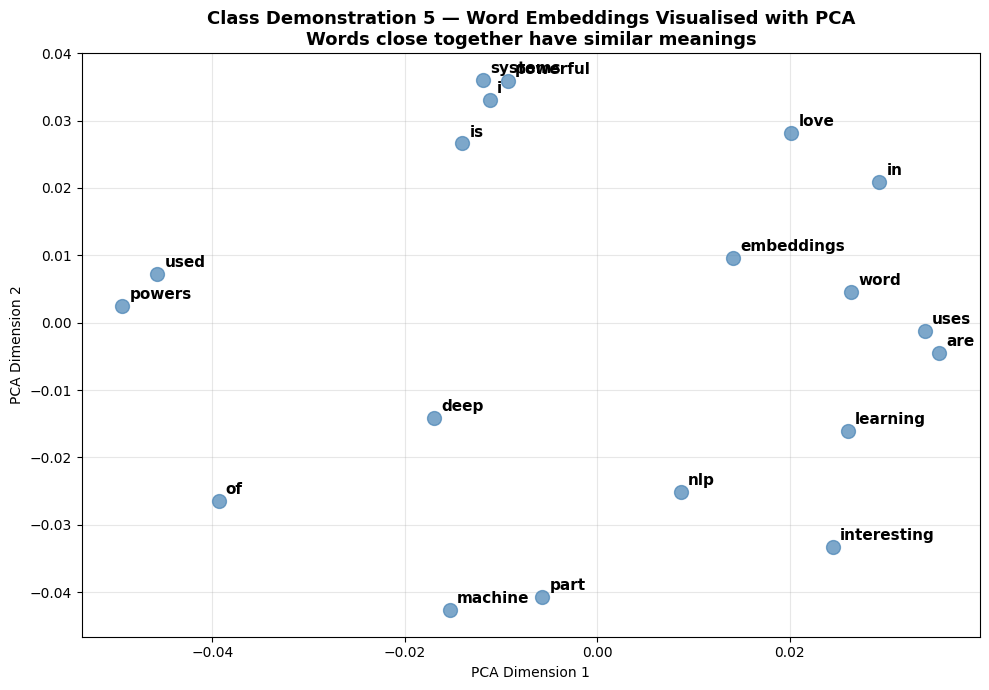


  Chart saved as demo5_word_embeddings_pca.png
  OBSERVATION: Words used in similar contexts
  appear closer together on the chart.


In [ ]:
# CLASS DEMONSTRATION 5: Visualizing Word Embeddings
# Word vectors have 50 dimensions — impossible to plot directly.
# PCA (Principal Component Analysis) reduces them to 2 dimensions
# so we can see which words cluster together on a 2D chart.
# Words that cluster close together have similar meanings.

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print('=' * 55)
print('  CLASS DEMONSTRATION 5 — Visualizing Word Embeddings')
print('  Using PCA to reduce 50D vectors to 2D for plotting')
print('=' * 55)

# Get all words and their vectors
words   = list(model.wv.index_to_key)
vectors = [model.wv[word] for word in words]

# Reduce from 50 dimensions to 2 using PCA
pca    = PCA(n_components=2)
coords = pca.fit_transform(vectors)

print(f'\n  Original dimensions : 50')
print(f'  After PCA           : 2')
print(f'  Words plotted       : {len(words)}')

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(coords[:, 0], coords[:, 1],
            color='steelblue', s=100, alpha=0.7, zorder=2)

for i, word in enumerate(words):
    plt.annotate(
        word,
        xy=(coords[i, 0], coords[i, 1]),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Class Demonstration 5 — Word Embeddings Visualised with PCA\n'
    'Words close together have similar meanings',
    fontsize=13, fontweight='bold'
)
plt.xlabel('PCA Dimension 1')
plt.ylabel('PCA Dimension 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('demo5_word_embeddings_pca.png', dpi=150)
plt.show()

print('\n  Chart saved as demo5_word_embeddings_pca.png')
print('  OBSERVATION: Words used in similar contexts')
print('  appear closer together on the chart.')
print('=' * 55)

### Class Activity 1: Comparing Representation Methods
**Task:** Represent the words Cat, Dog, Animal using
One-Hot Encoding and Word Embeddings then discuss differences.

In [ ]:
# CLASS ACTIVITY 1: Comparing Representation Methods
# We compare TWO ways computers represent words:
#
# METHOD 1 — One-Hot Encoding:
#   Each word gets a unique binary vector.
#   Cat=[1,0,0], Dog=[0,1,0], Animal=[0,0,1]
#   Problem: No relationship between words. Cat and Dog
#   are completely different even though both are animals.
#
# METHOD 2 — Word Embeddings:
#   Each word gets a vector of real numbers.
#   Similar words get similar vectors.
#   Cat and Dog will be close. Animal will be nearby too.

import numpy as np
from gensim.models import Word2Vec

print('=' * 60)
print('  CLASS ACTIVITY 1 — Comparing Representation Methods')
print('=' * 60)

# ── METHOD 1: One-Hot Encoding ──
vocabulary = ['cat', 'dog', 'animal']

print('\n  METHOD 1 — ONE-HOT ENCODING:')
print(f'  Vocabulary: {vocabulary}')
print()
print(f'  {"Word":<10} {"One-Hot Vector":<30} {"Vector Size"}')
print(f'  {"-"*55}')

one_hot_vectors = {}
for i, word in enumerate(vocabulary):
    vector = [0] * len(vocabulary)
    vector[i] = 1
    one_hot_vectors[word] = vector
    print(f'  {word:<10} {str(vector):<30} {len(vector)} dimensions')

# Check similarity in one-hot  should be 0 for all pairs
print()
print('  Similarity between words using One-Hot Encoding:')
pairs = [('cat', 'dog'), ('cat', 'animal'), ('dog', 'animal')]
for w1, w2 in pairs:
    v1 = np.array(one_hot_vectors[w1])
    v2 = np.array(one_hot_vectors[w2])
    dot = np.dot(v1, v2)
    print(f'  {w1} vs {w2}: similarity = {dot}')
    print(f'     → One-Hot shows NO relationship between these words!')

#  METHOD 2: Word Embeddings
print()
print('  METHOD 2 — WORD EMBEDDINGS (Word2Vec):')

animal_sentences = [
    ['cat',    'is',  'an',  'animal'],
    ['dog',    'is',  'an',  'animal'],
    ['cat',    'and', 'dog', 'are',   'pets'],
    ['animal', 'can', 'be',  'a',     'cat', 'or', 'dog'],
    ['cat',    'is',  'a',   'pet'],
    ['dog',    'is',  'a',   'pet'],
    ['animal', 'is',  'a',   'living', 'thing'],
    ['cat',    'and', 'dog', 'are',    'animals'],
]

animal_model = Word2Vec(
    animal_sentences,
    vector_size=20,
    window=3,
    min_count=1,
    epochs=200,
    sg=0
)

print()
print(f'  {"Word":<10} {"Embedding Vector (first 5 numbers)"}')
print(f'  {"-"*55}')
for word in ['cat', 'dog', 'animal']:
    vec = animal_model.wv[word][:5].round(3)
    print(f'  {word:<10} {vec}')

print()
print('  Similarity using Word Embeddings:')
for w1, w2 in pairs:
    score = animal_model.wv.similarity(w1, w2)
    print(f'  {w1} vs {w2}: similarity = {score:.4f}')
    print(f'     → Embeddings show the relationship!')

#  COMPARISON TABLE
print()
print('  COMPARISON SUMMARY:')
print(f'  {"Feature":<25} {"One-Hot Encoding":<22} {"Word Embeddings"}')
print(f'  {"-"*72}')
comparisons = [
    ('Vector Size',          'Large (= vocab size)',  'Small (fixed: 50-300)'),
    ('Meaning Captured',     'No',                    'Yes'),
    ('Semantic Relations',   'None',                  'Learned automatically'),
    ('Memory Efficiency',    'Very inefficient',      'Efficient'),
    ('Cat vs Dog similarity','0 (no relation)',       'High (both are pets)'),
]
for feature, ohe, emb in comparisons:
    print(f'  {feature:<25} {ohe:<22} {emb}')

print()
print('  CONCLUSION:')
print('  One-Hot Encoding treats every word as completely')
print('  different. Word Embeddings capture that cat and dog')
print('  are both animals and pets — a much smarter representation.')
print('=' * 60)

  CLASS ACTIVITY 1 — Comparing Representation Methods

  METHOD 1 — ONE-HOT ENCODING:
  Vocabulary: ['cat', 'dog', 'animal']

  Word       One-Hot Vector                 Vector Size
  -------------------------------------------------------
  cat        [1, 0, 0]                      3 dimensions
  dog        [0, 1, 0]                      3 dimensions
  animal     [0, 0, 1]                      3 dimensions

  Similarity between words using One-Hot Encoding:
  cat vs dog: similarity = 0
     → One-Hot shows NO relationship between these words!
  cat vs animal: similarity = 0
     → One-Hot shows NO relationship between these words!
  dog vs animal: similarity = 0
     → One-Hot shows NO relationship between these words!

  METHOD 2 — WORD EMBEDDINGS (Word2Vec):

  Word       Embedding Vector (first 5 numbers)
  -------------------------------------------------------
  cat        [-0.054  0.026 -0.044 -0.025  0.001]
  dog        [-0.008  0.002  0.025  0.042 -0.045]
  animal     [-0.007 

### Class Activity 2: Similarity Investigation
**Task:** Identify similar words, opposite words, and
related words using the trained embeddings.

In [ ]:
# CLASS ACTIVITY 2: Similarity Investigation
# We investigate three types of word relationships:
#
# SIMILAR WORDS   — words that mean the same thing
#                   e.g. student ↔ learner
# RELATED WORDS   — words connected in topic but not synonyms
#                   e.g. teacher ↔ school
# OPPOSITE WORDS  — words with contrasting meanings
#                   e.g. good ↔ bad
#
# We train on a richer dataset to see these relationships.

from gensim.models import Word2Vec

print('=' * 60)
print('  CLASS ACTIVITY 2 — Similarity Investigation')
print('=' * 60)

# Richer training dataset with similar, related, and opposite words
rich_sentences = [
    # Similar pairs
    ['student',  'learns',  'in',   'school'],
    ['learner',  'studies', 'in',   'school'],
    ['teacher',  'teaches', 'in',   'school'],
    ['lecturer', 'teaches', 'in',   'university'],
    ['student',  'and',     'learner', 'attend', 'class'],
    # Related pairs
    ['doctor',   'works',   'in',   'hospital'],
    ['nurse',    'works',   'in',   'hospital'],
    ['teacher',  'works',   'in',   'school'],
    ['school',   'and',     'university', 'are', 'education', 'institutions'],
    ['hospital', 'and',     'clinic',     'are', 'medical',   'institutions'],
    # Opposite pairs
    ['good',     'work',    'gets', 'high',  'marks'],
    ['bad',      'work',    'gets', 'low',   'marks'],
    ['pass',     'means',   'good', 'results'],
    ['fail',     'means',   'bad',  'results'],
    ['high',     'marks',   'lead', 'to',    'pass'],
    ['low',      'marks',   'lead', 'to',    'fail'],
    # NLP related
    ['nlp',      'is',      'natural', 'language', 'processing'],
    ['machine',  'learning', 'powers', 'nlp'],
    ['deep',     'learning', 'is',     'advanced', 'machine', 'learning'],
]

rich_model = Word2Vec(
    rich_sentences,
    vector_size=50,
    window=3,
    min_count=1,
    epochs=300,
    sg=1   # Skip-Gram — better for small datasets
)

#  SIMILAR WORDS
print('\n  1. SIMILAR WORDS (high similarity score — same meaning):')
print(f'  {"-"*55}')
similar_pairs = [
    ('student',  'learner'),
    ('teacher',  'lecturer'),
    ('school',   'university'),
    ('doctor',   'nurse'),
]
for w1, w2 in similar_pairs:
    if w1 in rich_model.wv and w2 in rich_model.wv:
        score = rich_model.wv.similarity(w1, w2)
        print(f'  {w1:<12} ↔ {w2:<12} : {score:.4f} — Similar words')

#  RELATED WORDS
print()
print('  2. RELATED WORDS (medium score — connected topic):')
print(f'  {"-"*55}')
related_pairs = [
    ('teacher',  'school'),
    ('doctor',   'hospital'),
    ('student',  'marks'),
    ('nlp',      'machine'),
]
for w1, w2 in related_pairs:
    if w1 in rich_model.wv and w2 in rich_model.wv:
        score = rich_model.wv.similarity(w1, w2)
        print(f'  {w1:<12} ↔ {w2:<12} : {score:.4f} — Related words')

#  OPPOSITE WORDS
print()
print('  3. OPPOSITE WORDS (note: embeddings learn from context,')
print('     so opposites often score HIGH — they appear in same context):')
print(f'  {"-"*55}')
opposite_pairs = [
    ('good',  'bad'),
    ('pass',  'fail'),
    ('high',  'low'),
]
for w1, w2 in opposite_pairs:
    if w1 in rich_model.wv and w2 in rich_model.wv:
        score = rich_model.wv.similarity(w1, w2)
        print(f'  {w1:<12} ↔ {w2:<12} : {score:.4f} — Opposite words')

print()
print('  INTERESTING FINDING:')
print('  Opposite words often score HIGH in Word2Vec because')
print('  they appear in the same context. "good" and "bad" both')
print('  appear near "marks", "work", "results" — so the model')
print('  places them close together even though they are opposites.')
print('  This is a known limitation of Word2Vec.')
print('=' * 60)

  CLASS ACTIVITY 2 — Similarity Investigation

  1. SIMILAR WORDS (high similarity score — same meaning):
  -------------------------------------------------------
  student      ↔ learner      : 0.8542 — Similar words
  teacher      ↔ lecturer     : 0.5512 — Similar words
  school       ↔ university   : 0.9002 — Similar words
  doctor       ↔ nurse        : 0.6098 — Similar words

  2. RELATED WORDS (medium score — connected topic):
  -------------------------------------------------------
  teacher      ↔ school       : 0.6662 — Related words
  doctor       ↔ hospital     : 0.7113 — Related words
  student      ↔ marks        : 0.8923 — Related words
  nlp          ↔ machine      : 0.9039 — Related words

  3. OPPOSITE WORDS (note: embeddings learn from context,
     so opposites often score HIGH — they appear in same context):
  -------------------------------------------------------
  good         ↔ bad          : 0.8680 — Opposite words
  pass         ↔ fail         : 0.8829 — Opp

### Class Activity 3: Real-World NLP Discussion
**Task:** Discuss how word embeddings improve search engines,
chatbots, recommendation systems, and translation systems.

In [ ]:
# CLASS ACTIVITY 3: Real-World NLP Discussion
# This activity demonstrates HOW word embeddings power real systems.
# We simulate each real-world application with a small example.

from gensim.models import Word2Vec

print('=' * 60)
print('  CLASS ACTIVITY 3 — Real-World NLP Applications')
print('  How Word Embeddings Power Everyday Technology')
print('=' * 60)

# APPLICATION 1: Search Engines
print('\n  APPLICATION 1 — SEARCH ENGINES')
print('  --------------------------------')
print('  Problem: User searches "cheap flights" but the page says')
print('           "affordable airfare" — same meaning, different words.')
print()
print('  How embeddings help:')
print('  → "cheap" and "affordable" have similar vectors')
print('  → "flights" and "airfare" have similar vectors')
print('  → Search engine finds the page even without exact words')
print()
print('  Real examples:')
print('  → Google Search    — semantic search')
print('  → Bing             — intent understanding')
print('  → Elasticsearch    — semantic document retrieval')

# APPLICATION 2: Chatbots
print()
print('  APPLICATION 2 — CHATBOTS')
print('  -------------------------')
print('  Problem: User types "I need help registering" but chatbot')
print('           only knows the phrase "unit registration".')
print()
print('  How embeddings help:')
print('  → "help" and "assistance" have similar vectors')
print('  → "registering" and "registration" have similar vectors')
print('  → Chatbot matches the intent even with different words')
print()
print('  Real examples:')
print('  → ChatGPT          — uses transformer embeddings')
print('  → Siri / Alexa     — voice intent matching')
print('  → Customer support — ticket classification')

#  APPLICATION 3: Recommendation Systems
print()
print('  APPLICATION 3 — RECOMMENDATION SYSTEMS')
print('  ----------------------------------------')
print('  Problem: User watched a movie about "space exploration".')
print('           System should recommend similar movies.')
print()
print('  How embeddings help:')
print('  → Movie titles and descriptions are embedded as vectors')
print('  → Similar topics cluster together in vector space')
print('  → System finds nearest vectors = similar movies')
print()
print('  Real examples:')
print('  → Netflix          — movie recommendations')
print('  → Spotify          — song recommendations')
print('  → Amazon           — product recommendations')

#  APPLICATION 4: Translation Systems
print()
print('  APPLICATION 4 — TRANSLATION SYSTEMS')
print('  -------------------------------------')
print('  Problem: Translate "Habari" (Swahili) to English.')
print()
print('  How embeddings help:')
print('  → Words in different languages with same meaning')
print('    get similar vector representations')
print('  → "Habari" vector ≈ "Hello" vector after training')
print('  → Model translates by finding the nearest vector')
print('    in the target language')
print()
print('  Real examples:')
print('  → Google Translate — 133 languages')
print('  → DeepL            — high-quality translation')
print('  → Microsoft Translator')

print()
print('  SUMMARY:')
print('  Word embeddings are the foundation that makes all these')
print('  systems work. Without them, computers would treat every')
print('  word as a completely unrelated symbol with no meaning.')
print('=' * 60)

  CLASS ACTIVITY 3 — Real-World NLP Applications
  How Word Embeddings Power Everyday Technology

  APPLICATION 1 — SEARCH ENGINES
  --------------------------------
  Problem: User searches "cheap flights" but the page says
           "affordable airfare" — same meaning, different words.

  How embeddings help:
  → "cheap" and "affordable" have similar vectors
  → "flights" and "airfare" have similar vectors
  → Search engine finds the page even without exact words

  Real examples:
  → Google Search    — semantic search
  → Bing             — intent understanding
  → Elasticsearch    — semantic document retrieval

  APPLICATION 2 — CHATBOTS
  -------------------------
  Problem: User types "I need help registering" but chatbot
           only knows the phrase "unit registration".

  How embeddings help:
  → "help" and "assistance" have similar vectors
  → "registering" and "registration" have similar vectors
  → Chatbot matches the intent even with different words

  Real examples:
 